In [10]:
#Python v3.11.8
#Import necessary packages

import os
import sys

import pandas as pd
import numpy as np

sys.path.append('functions')

from greatbrowser import great_analysis

from gene_analysis_functions import get_cistrome, get_pos, insig_nan
from pseudoinverse_functions import pinv_dropmin, quality_filter, trait_cluster

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
'''
Establich cwd, get relevant data, and perform basic formatting
'''

#set directory, import data, drop undefined
os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/raw_data')
data = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0) #mm39
data = data.dropna()

#referring to the point in the data where methylation and phenotype data diverge
sep=55

#seperate trait and methylation data
trait_data = data[:sep]
meth_data = data[sep:]

print(f'{trait_data.shape[0]} traits')

55 traits


In [12]:
#filter trait data to minimize colinearity
filter = 0.5
f_trait_data = quality_filter(trait_data, filter)

print(f'\n{f_trait_data.shape[0]} traits')

initializing: M12_poststress_GLU
M10_poststress_GLU corr: 0.6719015152375838
M8_poststress_GLU corr: 0.6090336912254721
removing: M8_poststress_GLU
M6_poststress_GLU corr: 0.5802400592602832
removing: M6_poststress_GLU
M4_poststress_GLU corr: 0.5311748134680883
removing: M4_poststress_GLU
M2_poststress_GLU corr: 0.3228813190001512
w4_stress_GLU corr: 0.3560799023117119
Baseline_GLU corr: 0.4321213022396831
M12_poststress_FFM_g corr: 0.016038987694264484
M10_poststress_FFM_g corr: 0.1032664053853798
M8_poststress_FFM_g corr: 0.13022424239458588
M6_poststress_FFM_g corr: 0.14497224377218185
M4_poststress_FFM_g corr: 0.13864898633105477
M2_poststress_FFM_g corr: 0.040837730206165726
w4_stress_FFM_g corr: 0.010086677800758868
Baseline_FFM_g corr: 0.04630001033314697
M12_poststress_FM_g corr: 0.15170584503159446
M10_poststress_FM_g corr: 0.3359654636524691
M8_poststress_FM_g corr: 0.30474076619102525
M6_poststress_FM_g corr: 0.5008174335569449
removing: M6_poststress_FM_g
M4_poststress_FM_g

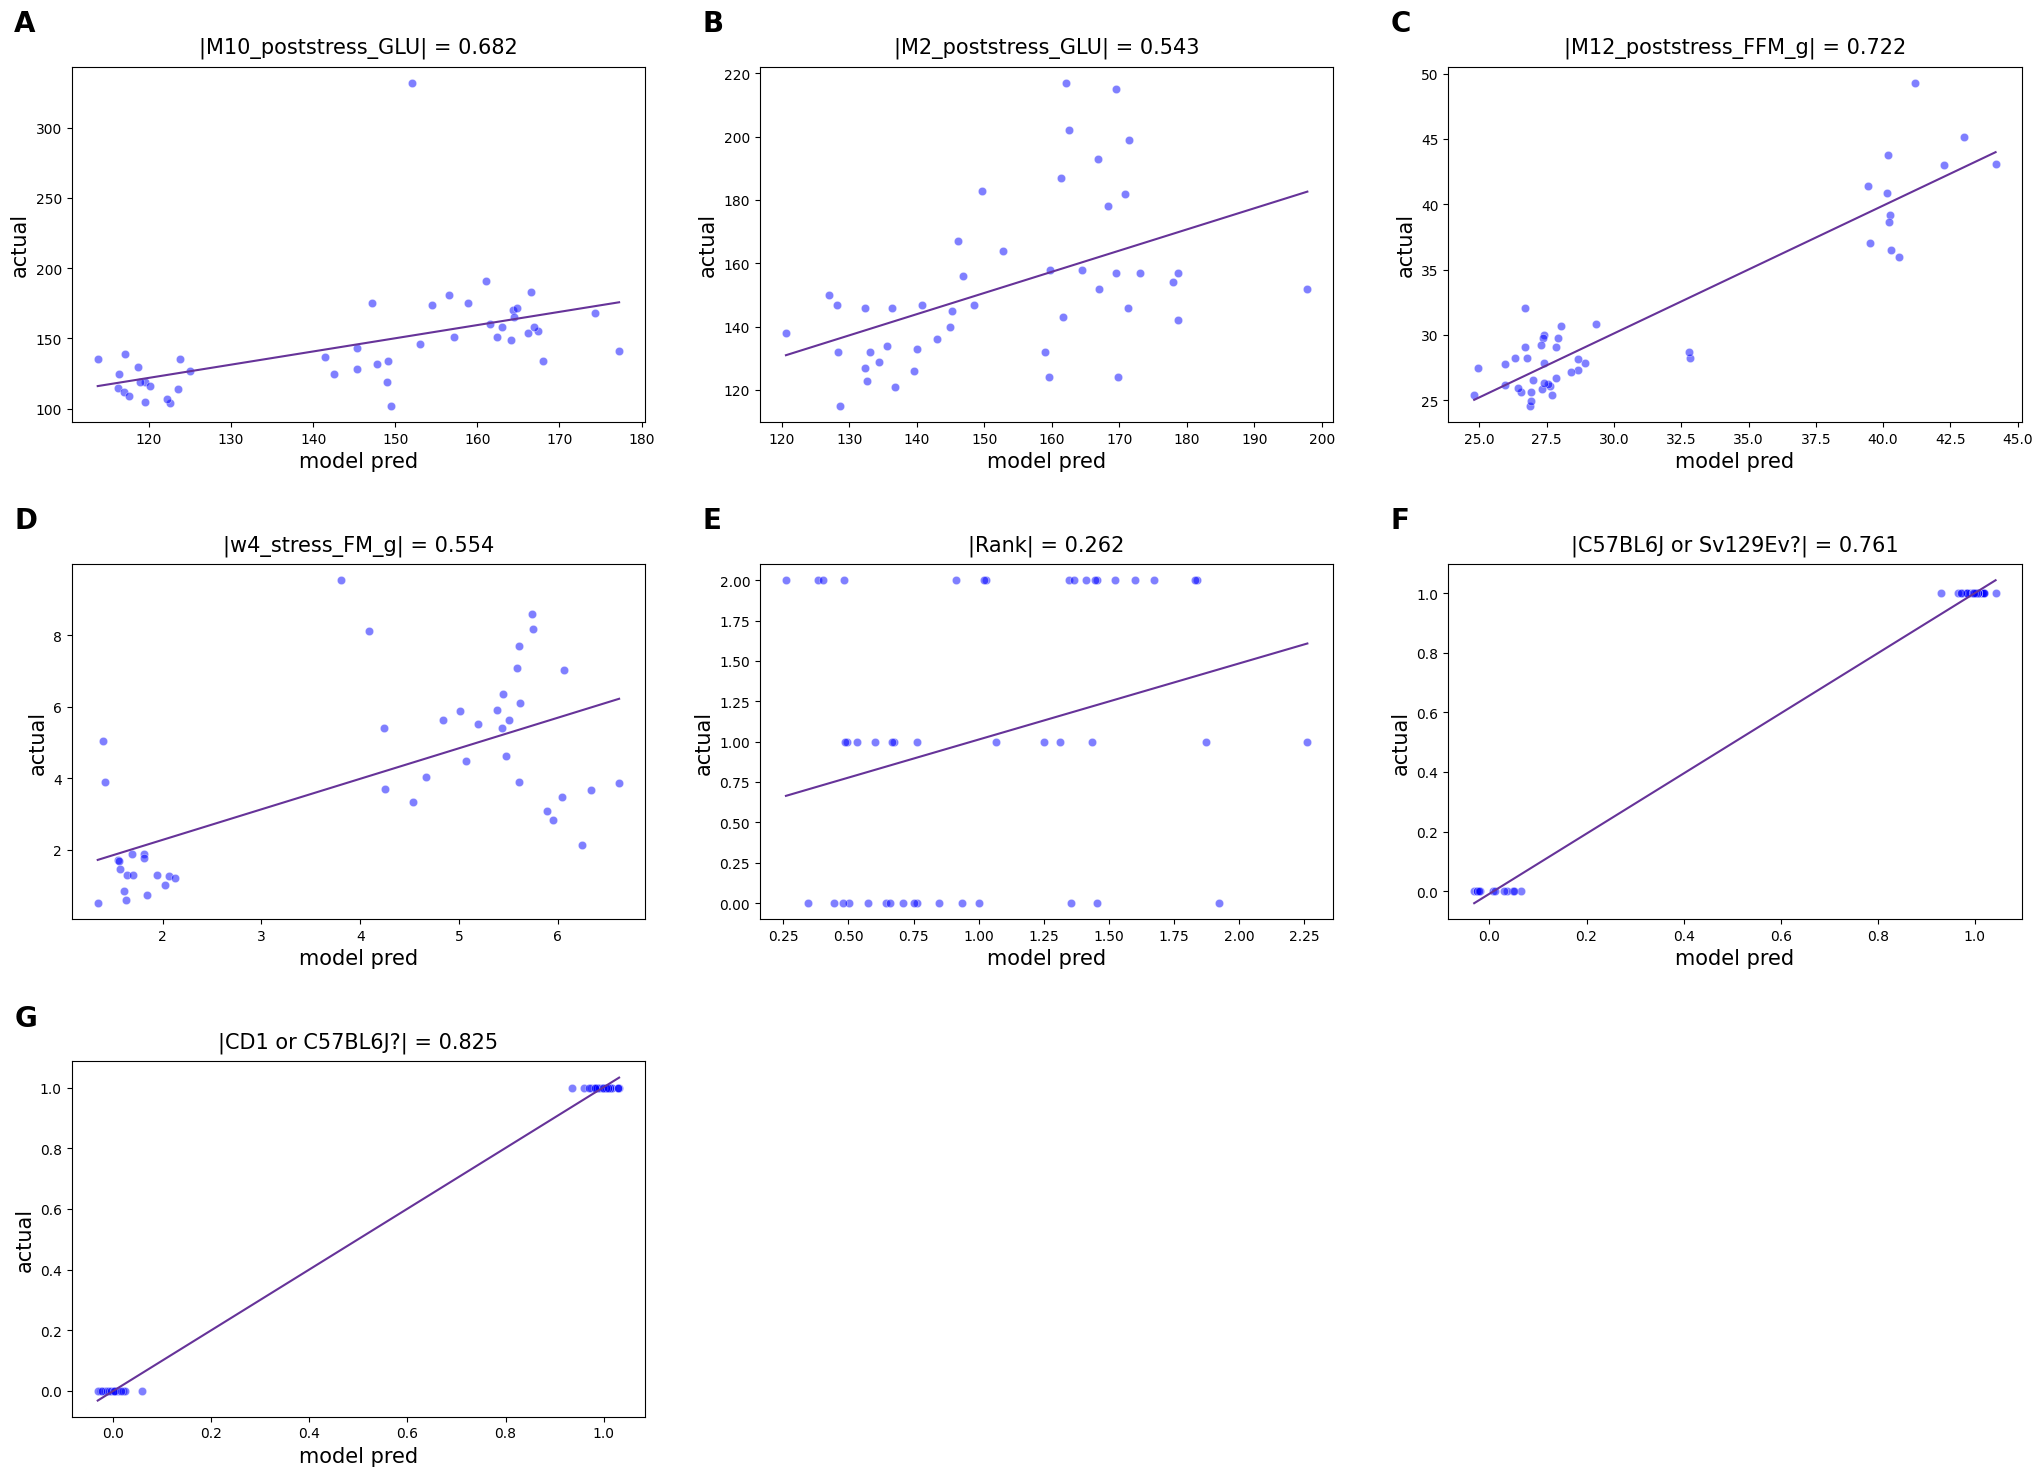

In [13]:
#generate pseudoinversion plots
thresh = 0.5
meth_filter_thresh = 0.5
pinv_dropmin(f_trait_data, meth_data, thresh, 
             find_meth=False, to_filter_meth=True, 
             meth_filter_thresh=meth_filter_thresh);

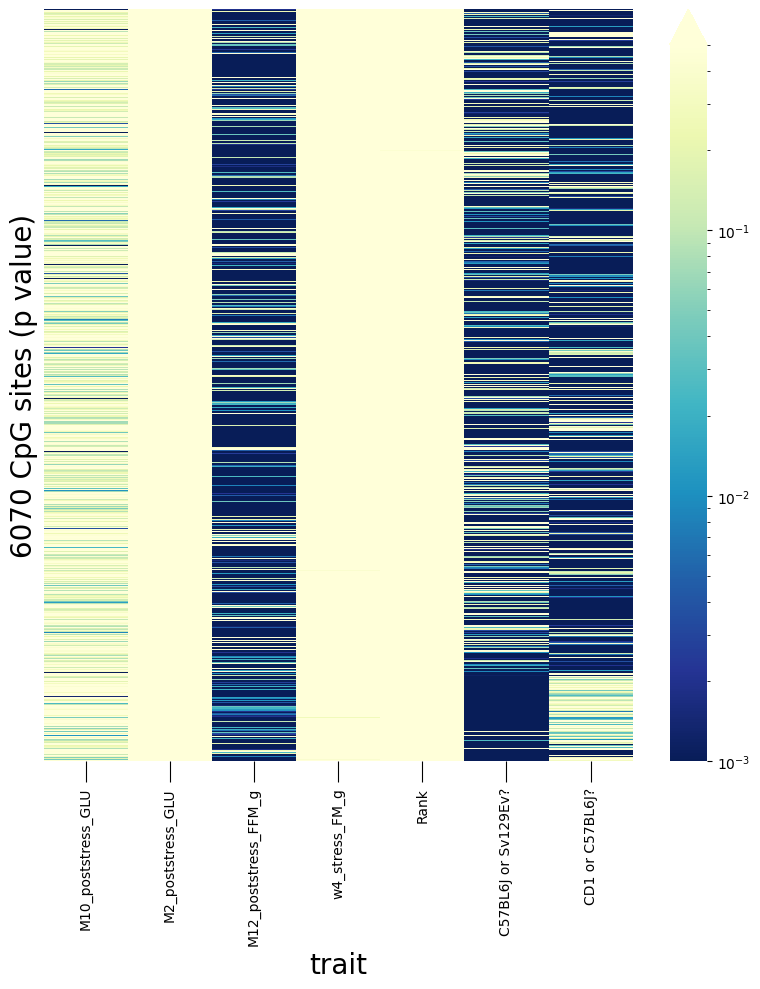

In [14]:
#generate heatmap of probe/trait multivar association p values
thresh = 0.5
meth_filter_thresh = 0.5
is_filtered = True
trait_vals, trait_pvals, trait_coef = pinv_dropmin(f_trait_data, meth_data, thresh, 
                                                   find_meth=True, plot_results=True, 
                                                   to_filter_meth=is_filtered, meth_filter_thresh=meth_filter_thresh);

In [15]:
#identify most significant probes
mm39_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(trait_vals, mm39_data);

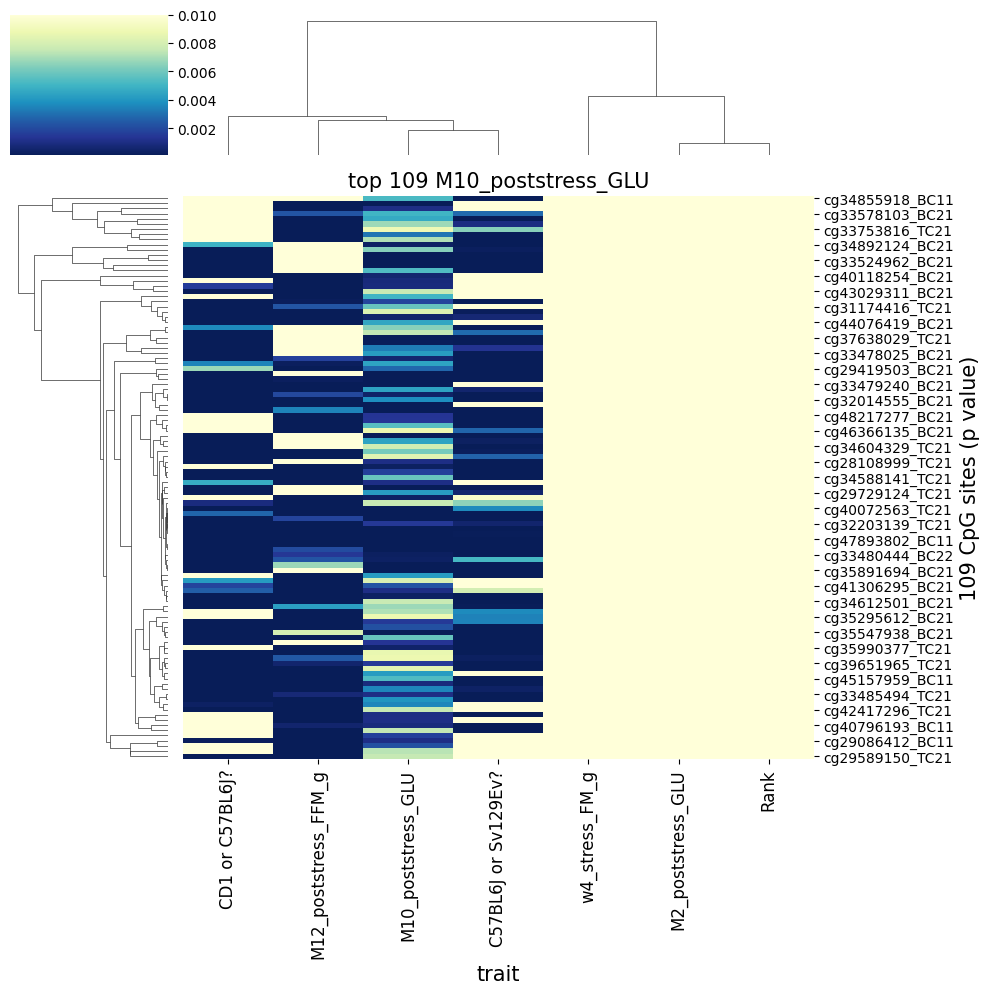

In [18]:
#generate a clustermap of significant probes for selected trait
sig_df = insig_nan(probe_df)
trait = 'M10_poststress_GLU_pval'

temp = sig_df[trait].values
temp = temp[~np.isnan(temp)]
n_probes = len(temp)

trait_cluster(trait_pvals, trait[:-5], n_probes);

In [19]:
#find gene associations of probes via GREAT

temp = probe_df.reset_index()
temp = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='index')

temp = temp.set_index('index')
trait_vals['associated_genes'] = temp['associated_genes']

if is_filtered:
    trait_vals.to_excel('pseudoinverse_probes_filtered.xlsx')
else:
    trait_vals.to_excel('pseudoinverse_probes_unfiltered.xlsx')

trait_vals

,M10_poststress_GLU_pval,M10_poststress_GLU_coef,M2_poststress_GLU_pval,M2_poststress_GLU_coef,M12_poststress_FFM_g_pval,M12_poststress_FFM_g_coef,w4_stress_FM_g_pval,w4_stress_FM_g_coef,Rank_pval,Rank_coef,...,C57BL6J or Sv129Ev?_coef,CD1 or C57BL6J?_pval,CD1 or C57BL6J?_coef,chr_mm39,pos_mm39,end_mm39,chr_mm10,pos_mm10,end_mm10,associated_genes
index,,,,,,,,,,,,,,,,,,,,,
cg20012035_TC21,0.161234,-0.000376,0.998288,0.000026,6.468150e-07,0.006126,0.706521,0.003143,0.999461,0.001320,...,0.238979,2.593553e-08,0.171391,chr12,111505954,111505956,chr12,111539520.0,111539522.0,"Mark3 (-35,006), Eif5 (+1,505)"
cg28108956_TC21,0.117653,-0.000382,0.997010,0.000028,1.091009e-11,0.008900,0.544886,0.005795,0.996526,-0.003038,...,0.225894,5.848290e-10,0.179340,chr6,40524504,40524506,chr6,40547570.0,40547572.0,"Prss37 (-28,063), Olfr461 (+7,479)"
cg28108999_TC21,0.001059,-0.000745,0.996633,-0.000063,1.357176e-02,0.002158,0.589599,0.003930,0.995287,0.003237,...,0.093388,4.287271e-10,0.166269,chr10,3207379,3207381,chr10,3257379.0,3257381.0,"H60c (+10,391)"
cg28113426_BC11,0.414004,-0.000140,0.996633,0.000196,6.826775e-02,0.001217,0.827669,-0.001135,0.808193,-0.008362,...,-0.012804,3.622431e-32,0.639228,chr10,3802852,3802854,chr10,3852852.0,3852854.0,"Mthfd1l (-120,278), Plekhg1 (+112,489)"
cg28116521_BC11,0.000043,-0.002461,0.996633,-0.000969,2.003947e-03,0.007301,0.544886,0.014020,0.987555,0.012713,...,0.288670,2.523759e-15,0.681934,chr10,4080228,4080230,chr10,4130228.0,4130230.0,"Akap12 (-136,151), Mthfd1l (+157,098)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48343432_BC11,0.581876,0.000639,0.996633,-0.001094,9.533655e-01,-0.000262,0.657609,0.015348,0.992193,0.017415,...,0.227849,8.652877e-08,0.657914,chrY,90751530,90751532,chrY,90740261.0,90740263.0,"Gm21996 (-994,730), Erdr1 (-44,476)"
cg48343860_TC21,0.336303,0.000603,0.996633,-0.000649,3.233402e-01,-0.002447,0.788307,0.005213,0.999461,0.003961,...,0.270623,8.356350e-13,0.608865,chrY,90771588,90771590,chrY,90760319.0,90760321.0,"Erdr1 (-24,418)"
cg48344016_TC11,0.443704,-0.000324,0.996633,-0.000246,4.302369e-10,0.013311,0.895746,0.001870,0.986751,-0.009499,...,0.204552,2.317898e-10,0.325355,chrY,90813306,90813308,chrY,90802037.0,90802039.0,"Erdr1 (+17,300)"


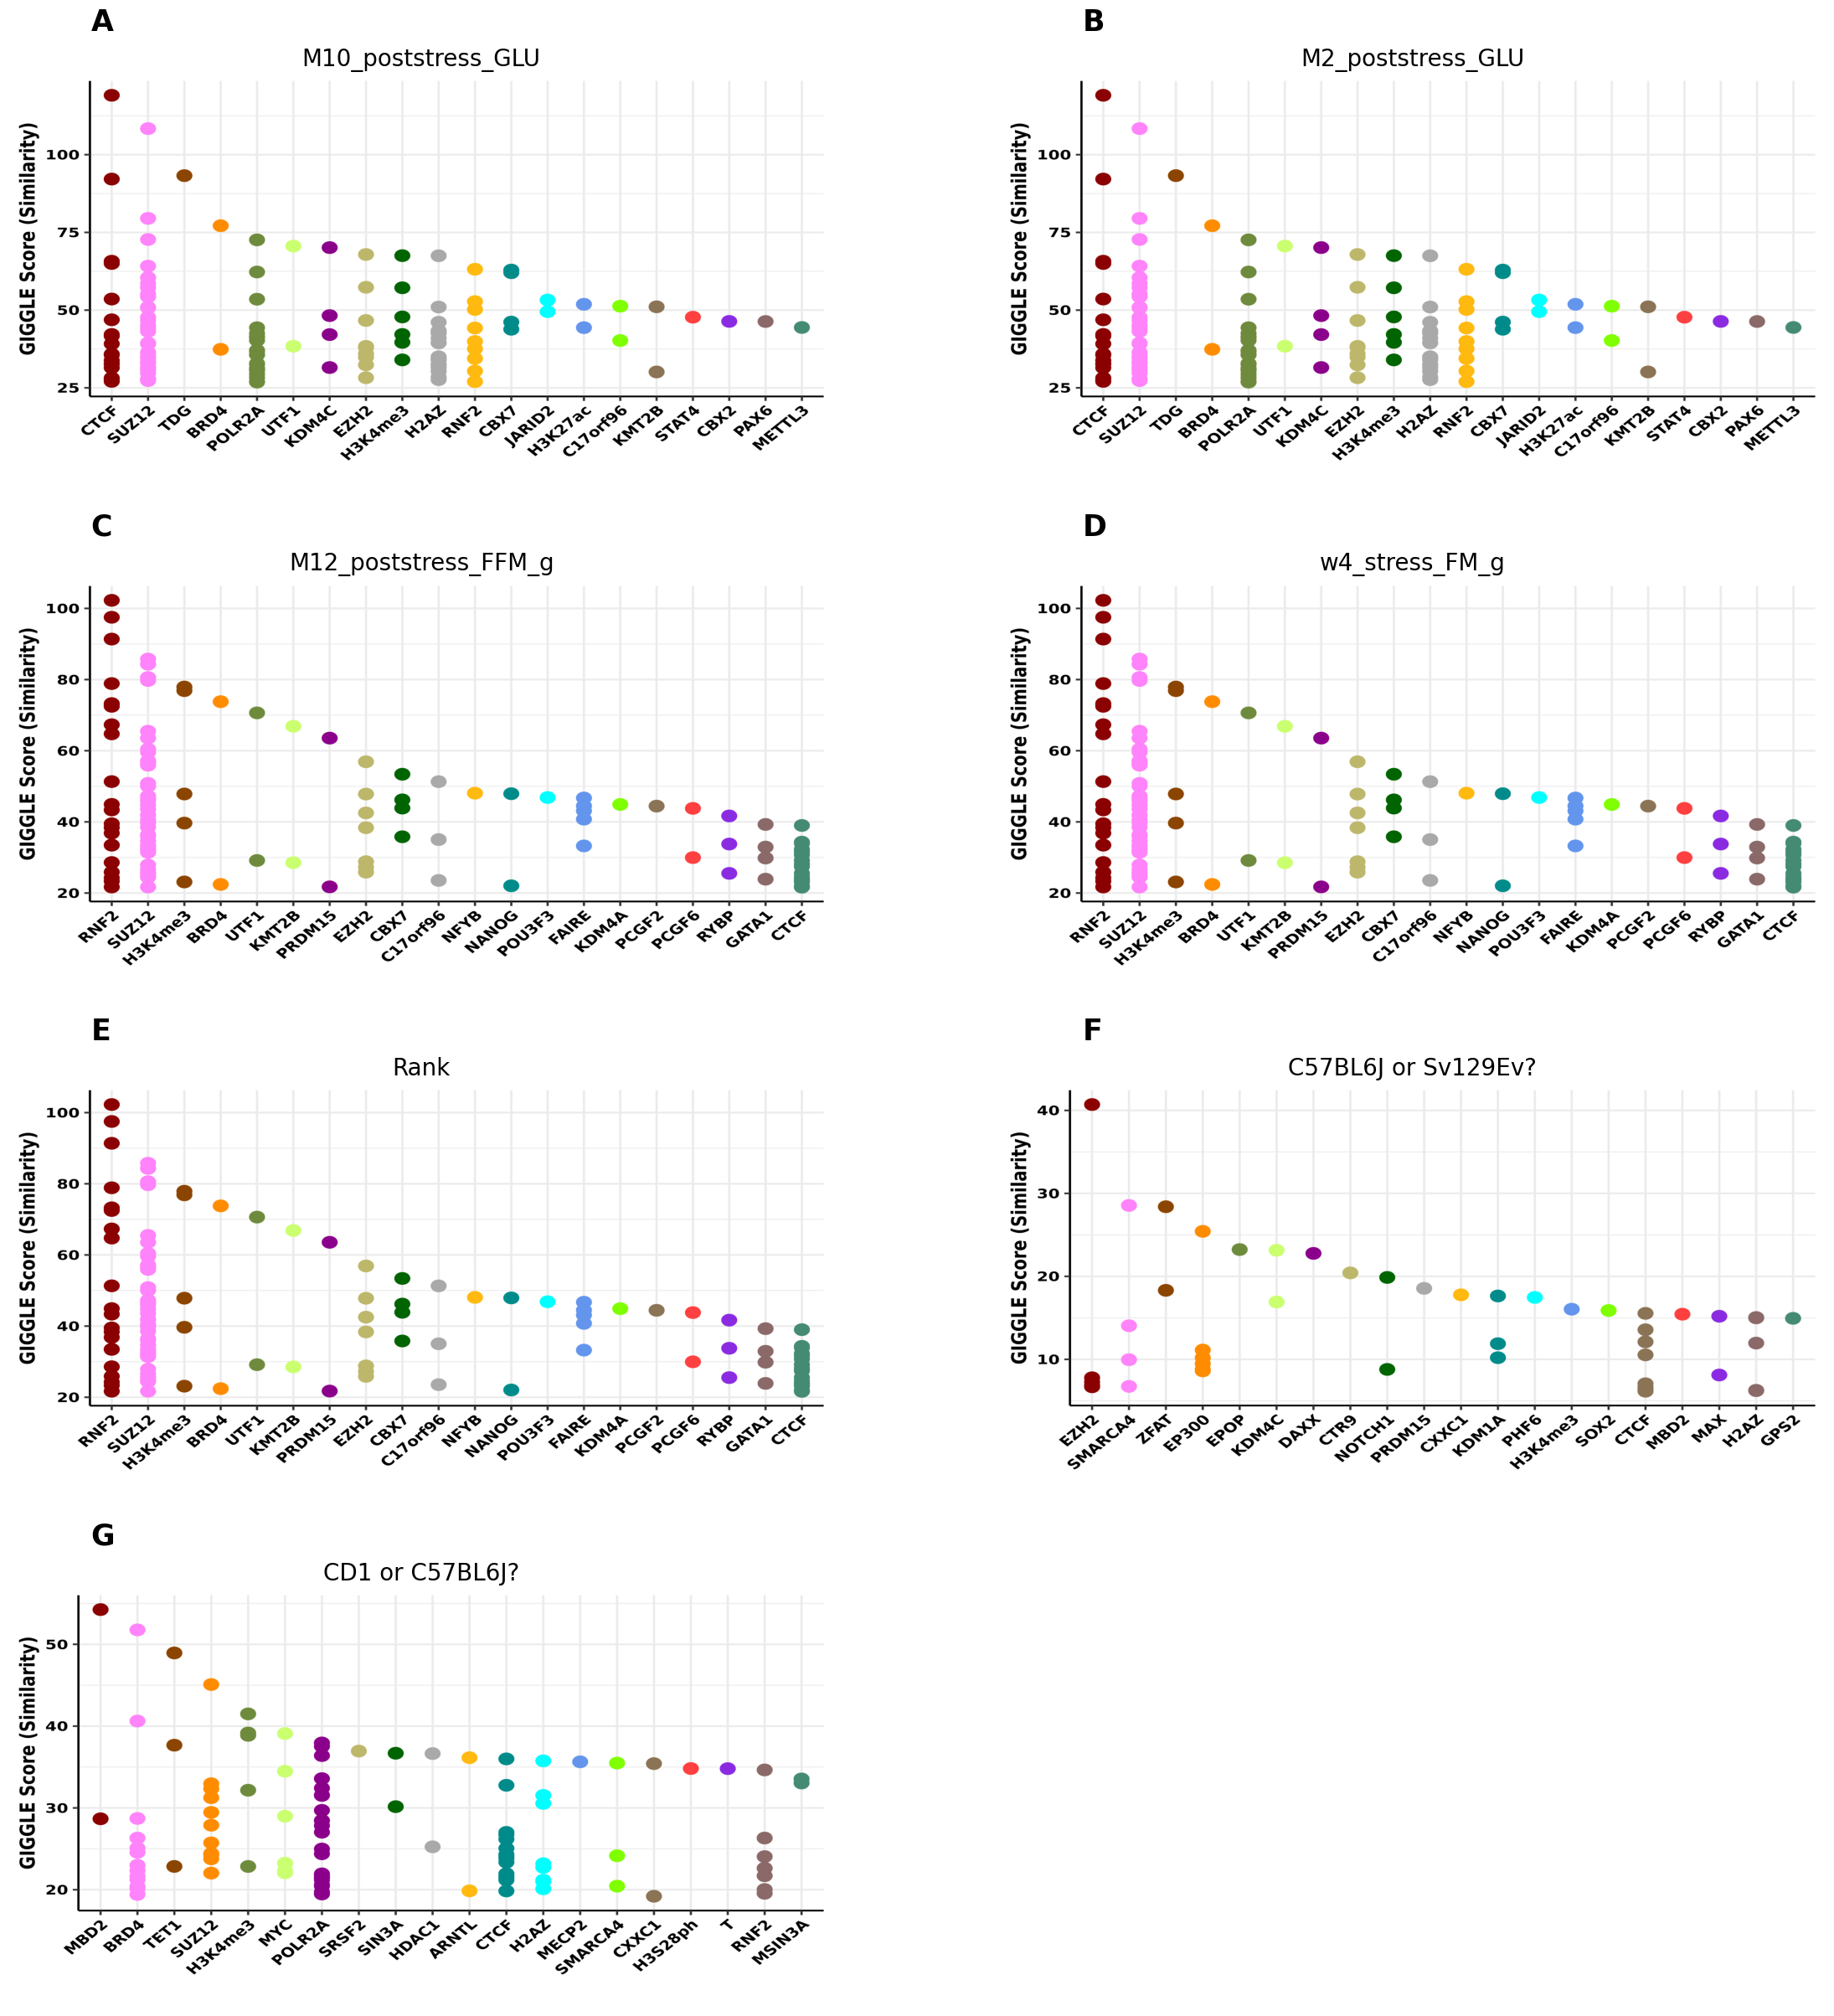

In [20]:
%matplotlib inline

#drop insignificant values
cistrome_df = insig_nan(trait_vals)

#this is trial and error, unfortunately 
fig_w = 2800
fig_h = 3000

#generate cistrome plots by trait for significant probes
get_cistrome(cistrome_df, fig_w, fig_h)